# Compulsory Assignment 2: Convolutional neural networks

Please fill out the group name, number, members and optionally the name below.

**Group number**: 19\
**Group member 1**: Matthieu Jouyit\
**Group member 2**: Paul-Adrien Lu-Yen-Tung\
**Group member 3**: Emre Can Emer\
**Group name (optional)**: 

### **08.10 Currently half of the assignment is done.**

# Assignment Submission
To complete this assignment answer the relevant questions in this notebook and write the code required to implement the relevant models. The assignment is submitted by handing in this notebook as an .ipynb file and as a .pdf file. 


# Introduction 
This assignment will start with classifying handwritten digits from the MNIST dataset, used in the voluntary assignment and the first compulsory assignment. The second part of this task will revolve around classifying the open-source Fashion-MNIST.



## Fashion-MNIST

The Fashion-MNIST is a dataset created from Zalando's article images(https://github.com/zalandoresearch/fashion-mnist/blob/master/README.md). The dataset consists of 70,000 labels images in 28x28 grayscale image labeled from 0 to 10. The goal of the Fashion-MNIST to work as a harder version of the handletter dataset MNIST. The Github repo for the dataset describe the dataset to be:
- "intend Fashion-MNIST to serve as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms."


<center><img src="fashion-mnist-sprite.png" width="500" height="400"></center>


# LeNet-5 Architecture Overview

**LeNet-5** (LeCun et al., 1998) is a foundational Convolutional Neural Network (CNN) designed for handwritten digit classification (MNIST). It established the classic deep learning workflow: alternating **Convolution** and **Pooling** layers to extract spatial features, followed by **Dense** layers for classification.

---

## 1. Network Pipeline

$$\text{Input Image} \longrightarrow \text{Conv1} \longrightarrow \text{Pool1} \longrightarrow \text{Conv2} \longrightarrow \text{Pool2} \longrightarrow \text{Flatten} \longrightarrow \text{FC1} \longrightarrow \text{FC2} \longrightarrow \text{Output}$$

---

## 2. Layer Specification Table

| Layer | Type | Configuration / Parameters | Activation |
| :--- | :--- | :--- | :--- |
| **C1** | Conv2D | 6 filters ($5 \times 5$), Padding='same' | `tanh` |
| **S2** | AvgPooling | Window: $2 \times 2$, Stride: 2 | — |
| **C3** | Conv2D | 16 filters ($5 \times 5$), Padding='valid' | `tanh` |
| **S4** | AvgPooling | Window: $2 \times 2$, Stride: 2 | — |
| **Flatten** | Reshape | Converts feature maps to 1D vector | — |
| **F5** | Dense | 120 neurons | `tanh` |
| **F6** | Dense | 84 neurons | `tanh` |
| **Output** | Dense | 10 neurons (Classes 0–9) | `softmax` |

---

## 3. Key Concepts for Students

* **Hierarchical Feature Extraction:** Early layers extract simple visual features (edges and lines), while deeper layers combine them into complex shapes (loops and intersections).
* **Spatial Invariance:** Subsampling (Pooling) reduces feature map resolution, making the model resilient to minor shifts or rotations in input images.
* **Evolution to Modern CNNs:**
  * **Activations:** Replaced historical `tanh` with `ReLU` to eliminate vanishing gradients.
  * **Pooling:** Replaced `AveragePooling` with `MaxPooling` for stronger feature selection.
  * **Normalization:** Added `BatchNorm` after convolution operations to accelerate convergence and stabilize training.
## Assignment structure

1. Part 1: Implementing LeNet for classifying MNIST.
2. Part 2: Designing your own CNN for classifying Fashion-MNIST
 

```python
prediction = model.predict(X_test)
flat_prediction = np.argmax(prediction, axis=1) # Flatten softmax predictions
submissionDF = pd.DataFrame()
submissionDF['ID'] = range(len(flat_prediction)) # The submission csv file must have an row index column called 'ID'
submissionDF['Prediction'] = flat_prediction
submissionDF.to_csv('submission.csv', index=False) # Remember to store the dataframe to csv without the nameless index column.
```

## Library imports

In [1]:
# Feel free to add or remove libraries as you want
import time

import numpy as np
import pandas as pd
import h5py

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tensorflow.keras as ks

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

SEED = 458
RNG = np.random.default_rng(SEED) # Random number generator

from utilities import *

# Part 1: CNN for classifying the MNIST dataset

## Loading MNIST

In [2]:
datasets = load_mnist(verbose=0)
X_train, y_train = datasets['X_train'], datasets['y_train']
X_val,   y_val   = datasets['X_val'],   datasets['y_val']
X_test,  y_test  = datasets['X_test'],  datasets['y_test']

X_train = np.concatenate([X_train, X_val], axis=0)
y_train = np.concatenate([y_train, y_val], axis=0).astype('int32')

# Seeing the shapes are useful for model setup later.
print('Training:   ', X_train.shape, y_train.shape)
print('Validation: ', X_val.shape, y_val.shape)
print('Test Set:   ', X_test.shape, y_test.shape)

del datasets, X_val, y_val # Good to reduce uneccesary RAM usage

Training:    (60000, 28, 28) (60000,)
Validation:  (10000, 28, 28) (10000,)
Test Set:    (10000, 28, 28) (10000,)


## Preprocessing

In [3]:
# Reshape data to account for color channel.
X_train = np.expand_dims(X_train, -1)
X_test  = np.expand_dims(X_test, -1)

# Normalizing input between [0,1].
X_train = X_train.astype("float32")/np.max(X_train)
X_test  = X_test.astype("float32")/np.max(X_test)

# Converting targets from numbers to categorical format.
y_train = ks.utils.to_categorical(y_train, len(np.unique(y_train)))
y_test  = ks.utils.to_categorical(y_test, len(np.unique(y_test)))

# Setting the input shape.
rows, columns = 28, 28
input_shape = (rows, columns, 1)

## Task 1.1: Build a CNN network with the LeNet5 architecture

##### Implement LeNet5 architecture according to the previous specifications: 

--------------------------


##### Compile the network with the
* `tf.keras.losses.CategoricalCrossentropy` loss function
* the `adam` optimizer 
* with the `accuracy` metric and (your own implementation of the) F1-score metric.

In [ ]:
# Setting up the architecture.
def lenet_architecture(input):
    lenet = ks.Sequential()

    # C1 conv2D layer.
    lenet.add(ks.layers.Conv2D(filters=6, kernel_size=[5,5], padding='same', 
                               activation='tanh', input_shape=input))

    # S2 AvgPooling layer.
    lenet.add(ks.layers.AveragePooling2D(pool_size=[2,2], strides=[2,2]))

    # C3 conv2D layer.
    lenet.add(ks.layers.Conv2D(filters=16, kernel_size=[5,5], padding='valid', 
                               activation='tanh', input_shape=input))

    # S4 AvgPooling layer.
    lenet.add(ks.layers.AveragePooling2D(pool_size=[2,2], strides=[2,2]))

    # Flatten layer.
    lenet.add(ks.layers.Flatten())

    # F5 dense layer.
    lenet.add(ks.layers.Dense(units=120, activation='tanh'))

    # F6 dense layer.
    lenet.add(ks.layers.Dense(units=84, activation='tanh'))

    # Output layer.
    lenet.add(ks.layers.Dense(units=10, activation='softmax'))

    return lenet

In [5]:
lenet_model = lenet_architecture(input_shape)
lenet_model.summary()

c:\Users\emryc\anaconda3\envs\dat300-env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Using the built-in F1-metrics as well as the external implementation.
lenet_model.compile(optimizer= 'adam', 
                    loss='categorical_crossentropy', 
                    metrics=['accuracy',
                             ks.metrics.F1Score(average='macro', name='f1_score')])

### Task 1.1.2 Train network

Train the network with a 
* batch size of 64 samples
* for 20 epochs
* 1/8 validation split

In [7]:
# y_onehot_train = tf.one_hot(y_train, 10)
training = lenet_model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=1, validation_split=1/8)

Epoch 1/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9172 - f1_score: 0.9161 - loss: 0.2778 - val_accuracy: 0.9605 - val_f1_score: 0.9602 - val_loss: 0.1315
Epoch 2/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9682 - f1_score: 0.9679 - loss: 0.1034 - val_accuracy: 0.9709 - val_f1_score: 0.9707 - val_loss: 0.0911
Epoch 3/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9805 - f1_score: 0.9803 - loss: 0.0650 - val_accuracy: 0.9781 - val_f1_score: 0.9779 - val_loss: 0.0727
Epoch 4/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9844 - f1_score: 0.9843 - loss: 0.0505 - val_accuracy: 0.9825 - val_f1_score: 0.9823 - val_loss: 0.0599
Epoch 5/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9878 - f1_score: 0.9877 - loss: 0.0392 - val_accuracy: 0.9800 - val_f1_score: 0.9797 - val_loss: 0.0637
Epoch 6/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9902 - f1_score: 0.9901 - loss: 0.0312 - val_accuracy: 0.9829 - val_f1_score: 0.9828

## Task 1.2 Evaluaiton
### Task 1.2.1 Plot training history and evaluate on test dataset

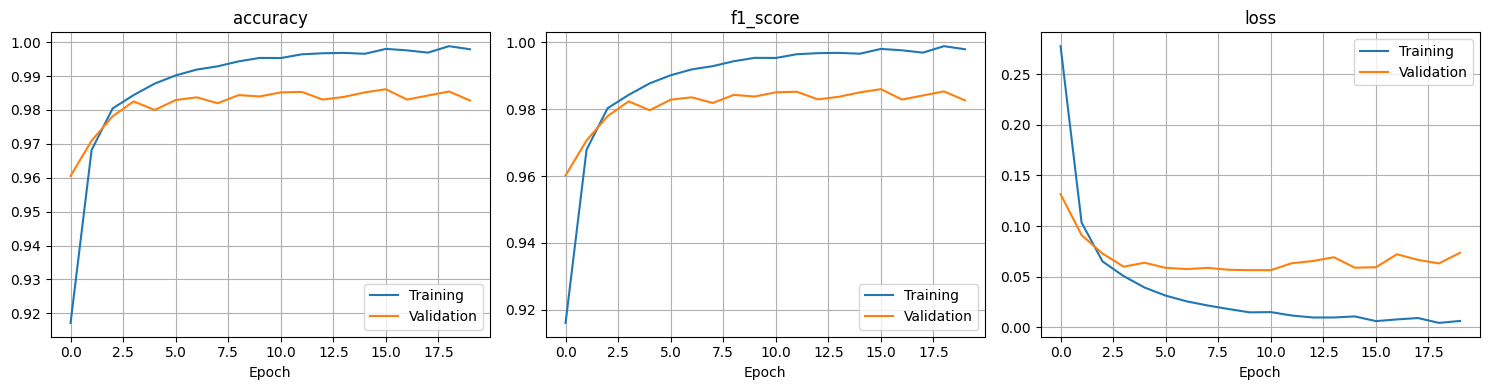

In [ ]:
# Using the provided plotting methods.
plot_training_history(training)

### Task 1.2.2 Evaluate on the test dataset

In [9]:
lenet_model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9852 - f1_score: 0.9851 - loss: 0.0549


[0.05492617189884186, 0.9851999878883362, 0.9851133227348328]

In [ ]:
# 10000*(1-0.987500011920929)
# Printing the shapes and flattening y labels, it causes problems otherwise.
print(y_train.shape)
print(y_test.shape)
y_test_true = np.argmax(y_test, axis=1)
y_train_true = np.argmax(y_train, axis=1)
print(y_train_true.shape)
print(y_test_true.shape)

(60000, 10)
(10000, 10)
(60000,)
(10000,)


### Task 2.2.3 Create a confution matrix for both traing and testing data
- Does the test data and train data predikt the same items wrong?

In [ ]:
# This is from the CNN lecture - 1 slides. Adjusted the teachers' code for this.
confusion_matrix(y_train_true,np.argmax(lenet_model.predict(X_train), axis=1), labels = list(range(10)))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


array([[5914,    0,    0,    0,    0,    2,    1,    1,    5,    0],
       [   1, 6715,    3,    0,    0,    0,    1,    2,   10,   10],
       [   4,    0, 5926,    4,    0,    0,    0,    3,   18,    3],
       [   0,    0,    6, 6110,    0,    2,    0,    1,    9,    3],
       [   0,    0,    3,    0, 5825,    0,    1,    3,    1,    9],
       [   0,    0,    1,    9,    0, 5391,    2,    0,    9,    9],
       [   4,    0,    3,    0,    1,    5, 5903,    0,    2,    0],
       [   0,    3,    2,    2,    0,    0,    0, 6186,   12,   60],
       [   1,    2,    1,    5,    0,    1,    1,    0, 5837,    3],
       [   0,    2,    1,    2,   21,    2,    0,    2,    6, 5913]])

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


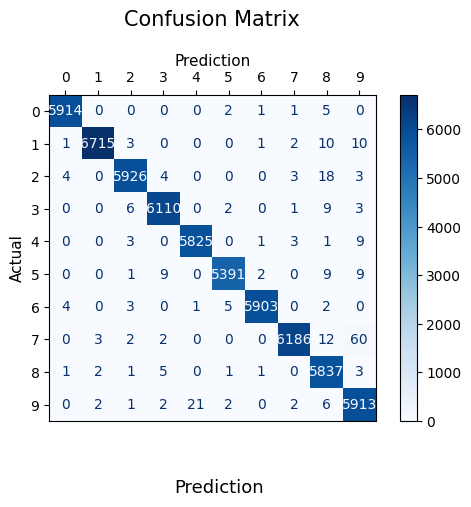

In [ ]:
# Decided to also draw a graph for better visualization.
cm = confusion_matrix(y_train_true, np.argmax(lenet_model.predict(X_train), axis=1), labels=list(range(10)))
# Using the confusion matrix display from sklearn.
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
# Code below is just for setting up the graph.
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=15, pad=20)
plt.xlabel('Prediction', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)

plt.show()

In [ ]:
# This is from the CNN lecture - 1 slides. Adjusted the teachers' code for this.
confusion_matrix(y_test_true,np.argmax(lenet_model.predict(X_test), axis=1), labels = list(range(10)))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[ 974,    0,    0,    0,    0,    1,    3,    1,    1,    0],
       [   0, 1124,    2,    2,    1,    0,    2,    1,    3,    0],
       [   1,    0, 1021,    2,    1,    1,    0,    1,    5,    0],
       [   0,    0,    0, 1003,    0,    1,    0,    0,    2,    4],
       [   1,    0,    4,    0,  969,    0,    2,    4,    1,    1],
       [   1,    0,    1,   10,    0,  875,    2,    1,    0,    2],
       [   4,    1,    2,    1,    0,    4,  943,    0,    3,    0],
       [   1,    0,    5,    6,    1,    0,    0, 1000,    3,   12],
       [   1,    0,    4,    3,    2,    1,    0,    0,  959,    4],
       [   3,    1,    1,    3,    9,    2,    0,    5,    1,  984]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


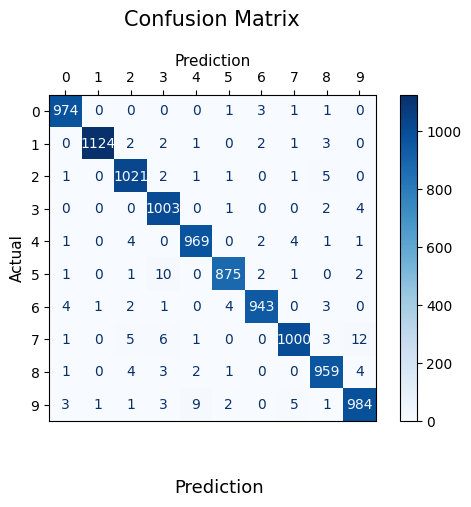

In [ ]:
# Decided to also draw a graph for better visualization.
cm = confusion_matrix(y_test_true, np.argmax(lenet_model.predict(X_test), axis=1), labels=list(range(10)))
# Using the confusion matrix display from sklearn.
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
# Code below is just for setting up the graph.
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=15, pad=20)
plt.xlabel('Prediction', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)

plt.show()

## Task 2.3: MNIST discussion

**Task 2.3.1: What is overfitting and how does it occur during training of the LeNet-5 model**

**Task 2.3.2: What is ReLU and Leaky ReLU, what is their derivative and how does their derivative solve the vanishing gradient problem?**

**Task 2.3.3: Calculate the numbers of weight and the output shape for the LeNet-5 at each layer, Show calculation**

Answer 2.3.1: Overfitting is when the model is training on the data, after certain epochs it starts to 'memorize' the data. Picking up on small details and noise. 

In the plot history of model training above, we can see that overfitting starts to occur at epoch 2. We think this because while the accuracy data curve keeps rising, validation data stagnates. This is a strong indication that the model is starting to overfit.

Answer 2.3.2: ReLu is an activation function. It basically returns the input as output if it's positive and returns zero if it's negative. Leaky ReLu is a version of ReLu which introduces a slope for the negative values. This also remedies (to a point) the 'dying ReLu' problem, in which neurons 'die' (if they return negative values, ReLu turns them into zeroes which in turn cause many null values in the network and it stops learning.)*

Since ReLu only allows positive gradients (negative values turn into zeroes), the derivates are either 0 or 1. This is an issue for tanh and sigmoid activation functions as they shrink gradients by the nature of their formulas.

Answer 2.3.3: Convolution formulas are taken from lecture notes.

C1 (Conv2D) layer: 
- Input is a (28, 28, 1) MNIST image file. We Use 6 filters and "same" padding, thus the output will be (28, 28, 6)
- Input doesn't matter for weights(params). We used a (5,5) filter. (5*5) * 6 + 6 = 156.
- Explanation: Filter is 5x5 = 25 pixels (weights) and we used 6 filters thus 150. Lastly, adding the 6 for bias for each filter.

S2 (AvgPooling) layer:
- Input is (28, 28, 6) from the previous C1 layer. Using "valid" padding.
- Formula for determining the size of convolution: $o = \left \lfloor{\frac{n+2p-m}{s}}\right \rfloor +1 $ 
- $n=28\:(input),m=2\:(kernel size),p=0\:(valid\:padding),s=2\:(stride)$

    $o = \left \lfloor{\frac{28+2*0-2}{2}}\right \rfloor +1 = 14$
- Pooling output will be (14, 14, 6).
- This is a window, there are no parameters.

C3 (Conv2D) layer:
- Input is (14, 14, 6) from the previous S2 layer.
- According to formula above:
- $n=14\:(input),m=5\:(kernel size),p=0\:(valid\:padding),s=0\:(stride)$

    $o = \left \lfloor{\frac{14+2*0-5}{1}}\right \rfloor +1 = 10$ 

- Input doesn't matter for weights(params). We used a (5,5) filter. ((5*5) * 6) * 16 + 16 = 2416 params.
- Explanation: Filter is 5x5 = 25 pixels (weights) and the input came with 6 filters thus 150. This convolution layer uses 16 filter which means 2400. Lastly, adding the 16 for bias for each filter.

S4 (AvgPooling) layer:
- Input is (10, 10, 16) from the previous C3 layer.
- Formula for determining the size of convolution: $o = \left \lfloor{\frac{n+2p-m}{s}}\right \rfloor +1 $ 
- $n=10\:(input),m=2\:(kernel size),p=0\:(padding),s=2\:(stride)$

    $o = \left \lfloor{\frac{10+2*0-2}{2}}\right \rfloor +1 = 5$
- Pooling output will be (5, 5, 6).
- This is a window, there are no parameters.

Flatten layer:
- This layer simply flattens the input so it can be used by the neural network in the next layer.
- Input is (5, 5, 6) from the previous S4 layer.
- Output is simply (5*5) * 6 = 400. From a 6 dimensional input with (5,5), now we have one dimensional output with (400,) dimensions.
- There are no parameters here, this layer simply flattens the data to one dimension.

F5 Dense layer:
- This is a neural network layer. It has 120 neurons thus the output is (120,).
- Input matters in dense layer, which is (400,). 120 * 400 + 120 = 48120 params.
- Explanation: Multiplying the input with the amount of neurons and then adding the bias for each neuron.

F6 Dense layer:
- This is a neural network layer. It has 84 neurons thus the output is (84,).
- Input matters in dense layer, which is (120,). 84 * 120 + 84 = 10164 params.
- Explanation: Same as above. Multiplying the input with the amount of neurons and then adding the bias for each neuron.

Output layer_
- There are 10 output possibilities. 10 classes so the output will be (10,)
- Input matters here too, which is (84,). 10 * 84 + 10 = 850 params.
- Explanation: Same as above. Multiplying the input with the amount of neurons and then adding the bias for each neuron.

*https://www.geeksforgeeks.org/deep-learning/relu-activation-function-in-deep-learning/

*https://www.geeksforgeeks.org/machine-learning/leaky-relu-activation-function-in-deep-learning/

# Task 2: CNN for classifying the Fashion-MNIST dataset

In this task you shall implement a CNN model, and train it to classify the images in the Fashion-MNIST dataset.

## Importing Fashion-MNIST

- Filename: `Fashion_MNIST.h5`

In [8]:
# Change this path
path = r"C:\Users\alfa\OneDrive - Norwegian University of Life Sciences\Desktop\AML_NMBU\DAT300\DAT300_2025\CA2_CNN_Template-1\Template\Fashion_MNIST.h5"
labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot" 
}

In [10]:
# 2. Use 'path' variable here
with h5py.File(path, 'r') as f:
    print('Datasets in file:', list(f.keys()))
    X_train = np.asarray(f['train_images'])
    y_train = np.asarray(f['train_labels'])
    X_test  = np.asarray(f['test_images'])
    print('Nr. train images: %i' % (X_train.shape[0]))
    print('Nr. test images: %i' % (X_test.shape[0]))

Datasets in file: ['test_images', 'train_images', 'train_labels']
Nr. train images: 59500
Nr. test images: 10500


## Task 2.1: Preprocess the data
Preprocess the data as you see fit

## Task 2.2: Visualize the dataset
Plot a few samples images and the distrbution of classes in the data. 

## Task 2.3: Build a CNN for classifying the Fashion-MNIST dataset
Build a CNN model 
- Experiment with different, Kernel sizes, stride, type/number of layers. 
- Don't overcomplicate and use it as grounds for discussion. 
- Tips, when you make changes to improve the model, save some earlier iterations.
- Only one model score higher than beat me.

# Task 2.5: Fashion-MNIST Discussion

### Task 3.5.1
- Feel Free to experiment on architecture
- Comment on the choice of layers and hyperparameters. 
    - Did you find some different results in changing a hyperparameter or add/remove a layer.
